# Note

This notebook is a summary of our previous repository for pollen detection. For interactive implementation and timely evaluation, here we use a lightweight model. As a result, the detection performance is not as good as we achieved in our paper. Please refer to more functions and details [here](https://github.com/fengzard/open_world_pollen_detection).

In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course. It is my habit to import them
ahead of time.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix
import matplotlib.patches as patches
import json, random, copy, time
from collections import OrderedDict


In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [3]:
# Set the global random seed for reproducibility
def seed_everything(seed=42):
    """
    Sets the random seed for reproducibility across multiple libraries and devices.
    """
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # set to False for deterministic behavior
    # torch.backends.cudnn.enabled = False # can be set to False if needed
    print(f"Random seed set to {seed}")

# Usage:
seed_everything(0)

Random seed set to 0


In [4]:
print(sys.version)
print(torch.__version__)


3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
2.10.0+cu128


In [5]:
# Check the specifications of your machine/what resources you have been allocated through Colab.
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Tue Mar 24 11:58:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:

# cpu or cuda? This code snippet will tell you.
device ='cpu'
if torch.cuda.is_available():
    device='cuda:0'
print(device)


cuda:0


In [7]:
from google.colab import drive # you can allow Google Colab to access your google drive, where you can save your data
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
root_folder = '/content/drive/MyDrive/MPC2026-shortcourse'
!ls $root_folder

cls_train.pkl			  dataset_for_detection_backup.zip
cls_val.pkl			  dataset_for_detection.zip
code011_detection_dataPrep.ipynb  meta_classification.txt
dataset_for_classification	  meta_detection.pkl
dataset_for_classification.zip	  slides
dataset_for_detection		  test-image.jpg


# Split the dataset into a training set and a validation set at slices level

In [20]:
# save this split for training and evaluation the model we will develop later
filename = os.path.join(root_folder, 'meta_detection.pkl')
with open(filename, 'rb') as file:
    datasetInfo = pickle.load(file)

train_imgList = datasetInfo['train_imgList']
train_maskList = datasetInfo['train_maskList']
valid_imgList = datasetInfo['valid_imgList']
valid_maskList = datasetInfo['valid_maskList']

In [21]:
train_imgList_cleanup = []
train_maskList_cleanup = []
valid_imgList_cleanup = []
valid_maskList_cleanup = []

for i in range(len(train_imgList)):
    if len(train_maskList[i])!=0 and [] not in train_maskList[i]:
        train_imgList_cleanup += [os.path.join(root_folder, train_imgList[i])]
        train_maskList_cleanup += [train_maskList[i]]
    else:
        print(train_imgList[i])

dataset_for_detection/40000x_54560y/5z.jpg
dataset_for_detection/45568x_53520y/5z.jpg
dataset_for_detection/58096x_56640y/4z.jpg
dataset_for_detection/45568x_42080y/5z.jpg
dataset_for_detection/49744x_54560y/5z.jpg
dataset_for_detection/49744x_58720y/5z.jpg
dataset_for_detection/51136x_54560y/5z.jpg
dataset_for_detection/49744x_45200y/3z.jpg
dataset_for_detection/48352x_58720y/5z.jpg
dataset_for_detection/48352x_58720y/6z.jpg
dataset_for_detection/40000x_56640y/5z.jpg
dataset_for_detection/49744x_46240y/4z.jpg
dataset_for_detection/58096x_41040y/3z.jpg
dataset_for_detection/45568x_45200y/5z.jpg


In [22]:
for i in range(len(valid_imgList)):
    if len(valid_maskList[i])!=0  and [] not in valid_maskList[i]:
        valid_imgList_cleanup += [os.path.join(root_folder, valid_imgList[i])]
        valid_maskList_cleanup += [valid_maskList[i]]
    else:
        print(valid_imgList[i])

dataset_for_detection/42784x_52480y/3z.jpg
dataset_for_detection/59488x_43120y/3z.jpg
dataset_for_detection/59488x_43120y/5z.jpg


In [23]:
train_imgList = train_imgList_cleanup
train_maskList = train_maskList_cleanup
valid_imgList = valid_imgList_cleanup
valid_maskList = valid_maskList_cleanup

print(len(train_imgList_cleanup), len(valid_imgList_cleanup))

164 40


# develop a helper function to create ground-truth for training deep learning models of pollen segmentation/detection.
The ground-truth is a distance transform map, measuring the distance from a pixel (within a pollen grain) to this grains circular boundary

# make a dataset class

In [33]:
class pollenDetectionDataset(Dataset):
    def __init__(self, imgList, maskList, transform=None, is_trainset=False):
        self.imgList = imgList
        self.maskList = maskList
        self.transform=transform
        self.current_set_len = len(imgList)
        self.is_trainset = is_trainset
        self.cropSize=[800,800]

    def __len__(self):
        return self.current_set_len

    def makeDistanceTransformMask(self, maskSize, valid_maskList):
        distTransformList = []
        for elm in valid_maskList:
            # Create a Circle patch object: center (x, y) and radius
            center_x = elm[3]
            center_y = elm[4]
            radius = elm[5]

            mask_x, mask_y = np.asarray(range(maskSize[1])).astype(np.float32), np.asarray(range(maskSize[0])).astype(np.float32)
            mask_x, mask_y = np.meshgrid(mask_x, mask_y)
            mask_x = float(center_x) - mask_x
            mask_y = float(center_y) - mask_y

            tmpDistTransform = radius-np.sqrt(mask_x*mask_x + mask_y*mask_y)
            tmpDistTransform[tmpDistTransform<0]=0
            distTransformList += [tmpDistTransform]
        if len(distTransformList)>1:
            distTransform = np.stack(distTransformList)
            distTransform = np.max(distTransform,0)
        else:
            distTransform = distTransformList[0]
        return distTransform


    def __getitem__(self, idx):
        cur_img = self.imgList[idx]
        cur_mask = self.maskList[idx]

        cur_img = skimage.io.imread(cur_img).astype(np.float32) / 255.0
        DistTransformMask = self.makeDistanceTransformMask(cur_img.shape[:2], cur_mask)

        cur_H, cur_W = cur_img.shape[:2]
        crop_topleft_h = cur_H - self.cropSize[0]
        crop_topleft_w = cur_W - self.cropSize[1]

        if self.is_trainset:
            crop_topleft_h = np.random.permutation(crop_topleft_h)[0]
            crop_topleft_w = np.random.permutation(crop_topleft_w)[0]
            cur_img = cur_img[crop_topleft_h:crop_topleft_h+self.cropSize[0],
                              crop_topleft_w:crop_topleft_w+self.cropSize[1],:]
            DistTransformMask = DistTransformMask[crop_topleft_h:crop_topleft_h+self.cropSize[0],
                                                  crop_topleft_w:crop_topleft_w+self.cropSize[1]]
        else:
            crop_topleft_h = np.random.permutation(crop_topleft_h)[0]
            crop_topleft_w = np.random.permutation(crop_topleft_w)[0]
            cur_img = cur_img[:self.cropSize[0], :self.cropSize[1], :]
            DistTransformMask = DistTransformMask[:self.cropSize[0], :self.cropSize[1]]

        if self.transform is not None:
            cur_img = self.transform(cur_img)

        binaryMask = copy.deepcopy(DistTransformMask)*0
        binaryMask[DistTransformMask>0] = 1

        DistTransformMask = torch.from_numpy(DistTransformMask).unsqueeze(0)
        binaryMask = torch.from_numpy(binaryMask).unsqueeze(0)
        return cur_img, DistTransformMask, binaryMask

In [34]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [35]:
trainset = pollenDetectionDataset(train_imgList,
                                  train_maskList,
                                  transform=data_transform,
                                  is_trainset=True
                                  )

valset = pollenDetectionDataset(valid_imgList,
                                valid_maskList,
                                transform=data_transform,
                                is_trainset=False
                                )

In [36]:
len(trainset), len(valset)

(164, 40)

In [37]:
batch_size = 4

dataloader_trainset = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
dataloader_valset = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)

print(len(dataloader_trainset), len(dataloader_valset))

41 10


In [38]:
i = 0
for sample in dataloader_valset:
    i+=1
    if i%10==0:
        print(i)
    cur_img, cur_disTransformMask, cur_binaryMask = sample
    cur_img = cur_img.to(device)
    cur_disTransformMask = cur_disTransformMask.to(device)
    cur_binaryMask = cur_binaryMask.to(device)

10


In [39]:
i = 0
for sample in dataloader_trainset:
    i+=1
    if i%10==0:
        print(i)
    cur_img, cur_disTransformMask, cur_binaryMask = sample
    cur_img = cur_img.to(device)
    cur_disTransformMask = cur_disTransformMask.to(device)
    cur_binaryMask = cur_binaryMask.to(device)

10
20
30
40


In [40]:
cur_img.shape, cur_disTransformMask.shape, cur_binaryMask.shape

(torch.Size([4, 3, 800, 800]),
 torch.Size([4, 1, 800, 800]),
 torch.Size([4, 1, 800, 800]))

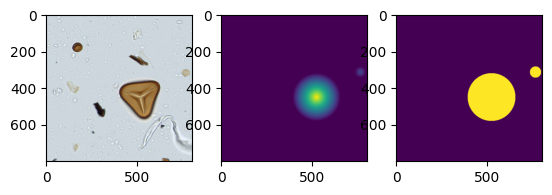

In [44]:
idx = 3


vis_img = cur_img[idx].permute(1,2,0).cpu().numpy()
vis_disTransformMask = cur_disTransformMask[idx].squeeze().cpu().numpy()
vis_binaryMask = cur_binaryMask[idx].squeeze().cpu().numpy()

plt.subplot(1, 3, 1) # 1 row, 2 columns, 1st plot
vis_img-=vis_img.min()
vis_img/=vis_img.max()
plt.imshow(vis_img)

plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
plt.imshow(vis_disTransformMask)


plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
plt.imshow(vis_binaryMask)

# Let's design a model

In [45]:
class ConvBlock(nn.Module):
    """Layer to perform a convolution followed by ELU
    """
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()

        self.conv = Conv3x3(in_channels, out_channels)
        self.nonlin = nn.ELU(inplace=True)

    def forward(self, x):
        out = self.conv(x)
        out = self.nonlin(out)
        return out

class Conv3x3(nn.Module):
    """Layer to pad and convolve input
    """
    def __init__(self, in_channels, out_channels, use_refl=True):
        super(Conv3x3, self).__init__()

        if use_refl:
            self.pad = nn.ReflectionPad2d(1)
        else:
            self.pad = nn.ZeroPad2d(1)
        self.conv = nn.Conv2d(int(in_channels), int(out_channels), 3)

    def forward(self, x):
        out = self.pad(x)
        out = self.conv(out)
        return out

def upsample(x):
    """Upsample input tensor by a factor of 2
    """
    return F.interpolate(x, scale_factor=2, mode="nearest")


class ResnetEncoder(nn.Module):
    """Pytorch module for a resnet encoder
    """
    def __init__(self, num_layers, pretrained):
        super(ResnetEncoder, self).__init__()
        self.path_to_model = './model'
        self.num_ch_enc = np.array([64, 64, 128, 256, 512])

        resnets = {18: models.resnet18, 34: models.resnet34, 50: models.resnet50,
                   101: models.resnet101, 152: models.resnet152}
        #resnets_pretrained_path = {18: 'resnet18-5c106cde.pth',
                                   #34: 'resnet34-333f7ec4.pth', 50: 'resnet50.pth', 101: 'resnet101.pth', 152: 'resnet152.pth'}


        if num_layers not in resnets:
            raise ValueError("{} is not a valid number of resnet layers".format(
                num_layers))

        self.encoder = resnets[num_layers]()

        if pretrained:
            print("using pretrained model")
            #self.encoder.load_state_dict(
                #torch.load(os.path.join(self.path_to_model, resnets_pretrained_path[num_layers])))
            checkpoint = torch.load(self.path_to_model)
            model.load_state_dict(checkpoint['model'])
            optimizer.load_state_dict(checkpoint['optimizer'])
            epoch = checkpoint['epoch']
            loss = checkpoint['loss']
            scheduler = checkpoint['lr_sched']

        if num_layers > 34:
            self.num_ch_enc[1:] *= 4

    def forward(self, input_image):
        self.features = []

        x = self.encoder.conv1(input_image)
        x = self.encoder.bn1(x)
        self.features.append(self.encoder.relu(x))
        self.features.append(
            self.encoder.layer1(self.encoder.maxpool(self.features[-1])))
        self.features.append(self.encoder.layer2(self.features[-1]))
        self.features.append(self.encoder.layer3(self.features[-1]))
        self.features.append(self.encoder.layer4(self.features[-1]))

        return self.features




class Decoder(nn.Module):
    def __init__(self, num_ch_enc, scaleList=(0, 1, 2, 3),
            num_output_channels=1, use_skips=True):
        super(Decoder, self).__init__()

        self.num_output_channels = num_output_channels
        self.use_skips = use_skips
        self.upsample_mode = 'nearest'
        self.scaleList = scaleList

        self.num_ch_enc = num_ch_enc
        self.num_ch_dec = np.array([16, 32, 64, 128, 256])

        # decoder
        self.convs = OrderedDict()
        for i in range(4, -1, -1):
            # upconv_0
            num_ch_in = self.num_ch_enc[-1] if i == 4 else self.num_ch_dec[i + 1]
            num_ch_out = self.num_ch_dec[i]
            self.convs[("upconv", i, 0)] = ConvBlock(num_ch_in, num_ch_out)

            # upconv_1
            num_ch_in = self.num_ch_dec[i]
            if self.use_skips and i > 0:
                num_ch_in += self.num_ch_enc[i - 1]
            num_ch_out = self.num_ch_dec[i]
            self.convs[("upconv", i, 1)] = ConvBlock(num_ch_in, num_ch_out)

        for s in self.scaleList:
            self.convs[("segMask", s)] = Conv3x3(self.num_ch_dec[s], 1)
            self.convs[("output", s)] = Conv3x3(self.num_ch_dec[s], self.num_output_channels)
            #self.convs[("outputAuxiliary", s)] = Conv3x3(self.num_ch_dec[s], self.num_output_channels)


        self.decoder = nn.ModuleList(list(self.convs.values()))
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()

    def forward(self, input_features):
        self.outputs = {}

        # decoder
        x = input_features[-1]
        for i in range(4, -1, -1):
            x = self.convs[("upconv", i, 0)](x)
            x = [upsample(x)]
            if self.use_skips and i > 0:
                x += [input_features[i - 1]]
            x = torch.cat(x, 1)
            x = self.convs[("upconv", i, 1)](x)
            if i in self.scaleList:
                self.outputs[("segMask", i)] = self.sigmoid(self.convs[("segMask", i)](x))
                self.outputs[("output", i)] = self.convs[("output", i)](x)

        return self.outputs

In [46]:
class PollenDet_SegDistTransform(nn.Module):
    def __init__(self, num_layers, scaleList=(0,1,2,3), pretrained=False):
        super(PollenDet_SegDistTransform, self).__init__()
        self.scaleList = scaleList
        self.encoder = ResnetEncoder(num_layers, pretrained)
        self.encoder.encoder.conv1 = nn.Conv2d(21, 64, (7, 7), (2, 2), (3, 3), bias=False) #added 10/07/21
        self.decoder = Decoder(self.encoder.num_ch_enc, scaleList=self.scaleList, num_output_channels=1)

    def forward(self, inputs1):
        inputs = (inputs1 )
        features = self.encoder(inputs)
        # for i in range(len(features)):
        #     print(features[i].shape)
        outputs = self.decoder(features)
        return outputs

In [47]:
scaleList = [0]           # the number of output layer for U-net


################## init model ###################
initModel = PollenDet_SegDistTransform(34, scaleList=scaleList, pretrained=True)
initModel.encoder.encoder.conv1 = nn.Conv2d(3, 64, (7, 7), (2, 2), (3, 3), bias=False) #change dimensions of the first layer in the encoder
initModel = initModel.to(device);

# # print(initModel.encoder.encoder)

In [48]:
output_masks = initModel(cur_img)
# cur_mask = cur_mask.to(device)

In [49]:
output_masks.keys()

dict_keys([('segMask', 0), ('output', 0)])

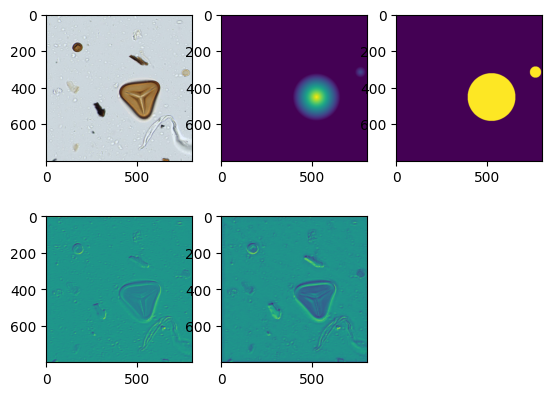

In [50]:

plt.subplot(2, 3, 1) # 1 row, 2 columns, 1st plot
plt.imshow(vis_img)

plt.subplot(2, 3, 2) # 1 row, 3 columns, 2nd plot
plt.imshow(vis_disTransformMask)

plt.subplot(2, 3, 3) # 1 row, 3 columns, 3rd plot
plt.imshow(vis_binaryMask)

plt.subplot(2, 3, 4) # 1 row, 2 columns, 1st plot
tmp = output_masks[("segMask", 0)][idx].squeeze().detach().cpu().numpy()
plt.imshow(tmp)

plt.subplot(2, 3, 5) # 1 row, 2 columns, 1st plot
tmp = output_masks[("output", 0)][idx].squeeze().detach().cpu().numpy()
plt.imshow(tmp)

# configure training including loss function, optimizer, etc.

In [51]:
base_lr =0.0005           # base learning rate
total_epoch_num = 30      # total number of epoch in training
weight_background = 0.1   # For regression loss only, downweights background pixels to highlight foreground pollen
weight_reg = 2.0    # Balances regression loss with segmentation loss. Value chosen based on past investigation.

In [52]:
# loss for regression with masking
class MaskWeightedL1(nn.Module):
    def __init__(self, wBG=0.5, wFactor=1):
        super(MaskWeightedL1, self).__init__()
        self.wBG = wBG
        self.wFactor = wFactor

    def forward(self, inputs, target, segMask):
        N, C, H, W = inputs.shape    #if mask only has 1 channel, C=1
        output = inputs - target
        totalNum = H * W * N
        output = torch.abs(output)
        output = torch.mean(output, 1, keepdim=True)

        output = output * (segMask + self.wBG)

        lossValue = output.sum() / totalNum
        return lossValue*self.wFactor

In [53]:
# loss for (binary) segmentation
weight = torch.ones(2)
weight[0] = 0.5
weight = weight.to(device)
#lossFunc_seg = nn.CrossEntropyLoss(weight=weight, reduction='elementwise_mean')
lossFunc_seg = nn.BCELoss(reduction='mean')

# loss for regression with masking
lossFunc_reg = MaskWeightedL1(wBG=weight_background, wFactor=weight_reg)

In [54]:
optimizer = optim.Adam([{'params': initModel.encoder.parameters()},
                        {'params': initModel.decoder.parameters()}],
                       lr=base_lr, weight_decay=0.0005)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=int(total_epoch_num/4), gamma=0.4)

In [55]:
project_name = 'detector_training'
trial = 'trial_01'
exp_dir = './exp'

exp_dir = os.path.join(exp_dir, project_name)
save_dir = os.path.join(exp_dir, trial) # Location to save log file and trained models.
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
log_filename = os.path.join(save_dir, 'train.log')

################## start training ###################
fn = open(log_filename,'w')
fn.write(log_filename+'\t'+device+'\n\n')
fn.close()
file_to_note_bestModel = os.path.join(save_dir,'note_bestModel.log')
fn = open(file_to_note_bestModel, 'w')
fn.write('Record of best models on the way.\n')
fn.close()

In [56]:
since = time.time()
best_model_wts = copy.deepcopy(initModel.state_dict())
best_loss = float('inf')

In [57]:
best_epoch_id = -1
best_loss = torch.inf

for epoch in range(total_epoch_num):        # total_epoch_num
    print('\nEpoch {}/{}'.format(epoch+1, total_epoch_num))
    print('-' * 10)
    fn = open(log_filename,'a')
    fn.write('\nEpoch {}/{}\n'.format(epoch+1, total_epoch_num))
    fn.write('--'*5+'\n')
    fn.close()

    # Each epoch has a training and validation phase
    phase = 'training'
    print(phase)
    fn = open(log_filename,'a')
    fn.write(phase+'\n')
    fn.close()

    initModel.train()  # Set model to training mode


    running_loss = 0.0
    running_loss_seg = 0.
    running_loss_reg = 0.
    countSmpl = 0.

    # Iterate over data.
    iterCount, sampleCount = 0, 0
    for sample in dataloader_trainset:
        cur_img, cur_disTransformMask, cur_binaryMask = sample
        cur_img = cur_img.to(device)
        cur_disTransformMask = cur_disTransformMask.to(device)
        cur_binaryMask = cur_binaryMask.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward
        # track history if only in train
        loss = 0
        with torch.set_grad_enabled(True):
            outputs = initModel(cur_img)

            for ii in range(len(scaleList)):
                predSeg = outputs[('segMask', ii)]
                predDistTransform = outputs[('output', ii)]

                loss_seg = 0
                loss_reg = 0
                loss_seg = lossFunc_seg(predSeg, cur_binaryMask)

                loss_reg = lossFunc_reg(cur_disTransformMask, predDistTransform, cur_binaryMask)
                # loss_reg = lossFunc_reg(grndDistTransform, predDistTransform, grndSeg)
                loss += loss_seg + loss_reg

            # backward + optimize only if in training phase
            loss.backward()
            optimizer.step()


        iterCount += 1
        sampleCount += cur_binaryMask.size(0)
        running_loss_seg += loss_seg.item() * cur_binaryMask.size(0)
        running_loss_reg += loss_reg.item() * cur_binaryMask.size(0)

        print2screen_avgLoss_seg = running_loss_seg / sampleCount
        print2screen_avgLoss_reg = running_loss_reg / sampleCount
        epoch_loss = print2screen_avgLoss_seg + print2screen_avgLoss_reg

        if iterCount%10==0:
            print('\t{}/{} seg:{:.3f}, reg:{:.3f}, total loss {:.3f}'.
                  format(iterCount, len(dataloader_trainset),
                         print2screen_avgLoss_seg,
                         print2screen_avgLoss_reg,
                         epoch_loss)
                  )

    exp_lr_scheduler.step()

    initModel.eval()   # Set model to evaluate mode
    running_loss = 0.0
    running_loss_seg = 0.
    running_loss_reg = 0.
    for sample in dataloader_valset:
        cur_img, cur_disTransformMask, cur_binaryMask = sample
        cur_img = cur_img.to(device)
        cur_disTransformMask = cur_disTransformMask.to(device)
        cur_binaryMask = cur_binaryMask.to(device)

        outputs = initModel(cur_img)
        for ii in range(len(scaleList)):
            predSeg = outputs[('segMask', ii)]
            predDistTransform = outputs[('output', ii)]
            loss_seg = 0
            loss_reg = 0
            loss_seg = lossFunc_seg(predSeg, cur_binaryMask)
            loss_reg = lossFunc_reg(cur_disTransformMask, predDistTransform, cur_binaryMask)
            # loss_reg = lossFunc_reg(grndDistTransform, predDistTransform, grndSeg)
            loss = loss_seg + loss_reg
        iterCount += 1
        sampleCount += cur_binaryMask.size(0)
        running_loss_seg += loss_seg.item() * cur_binaryMask.size(0)
        running_loss_reg += loss_reg.item() * cur_binaryMask.size(0)

    print2screen_avgLoss_seg = running_loss_seg / sampleCount
    print2screen_avgLoss_reg = running_loss_reg / sampleCount
    epoch_loss = print2screen_avgLoss_seg + print2screen_avgLoss_reg
    # best_epoch_id = -1
    # best_loss = torch.inf
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch_id = epoch
        bestmodel_filename = './bestValModel.pt'
        torch.save(initModel.state_dict(), bestmodel_filename)
        # path_to_save_paramOnly = os.path.join(work_dir, 'bestValModel_encoder.paramOnly')
        # torch.save(initModel.state_dict(), path_to_save_paramOnly)
        # path_to_save_checkpoint = os.path.join(work_dir, 'bestValModel.pt')
        # torch.save(checkpoint, path_to_save_checkpoint)


Epoch 1/30
----------
training
	10/41 seg:0.415, reg:1.830, total loss 2.245
	20/41 seg:0.287, reg:2.179, total loss 2.467
	30/41 seg:0.242, reg:2.343, total loss 2.585
	40/41 seg:0.211, reg:2.361, total loss 2.572

Epoch 2/30
----------
training
	10/41 seg:0.104, reg:1.402, total loss 1.506
	20/41 seg:0.089, reg:1.239, total loss 1.328
	30/41 seg:0.103, reg:1.458, total loss 1.561
	40/41 seg:0.106, reg:1.689, total loss 1.795

Epoch 3/30
----------
training
	10/41 seg:0.103, reg:1.854, total loss 1.957
	20/41 seg:0.095, reg:1.472, total loss 1.567
	30/41 seg:0.102, reg:1.776, total loss 1.878
	40/41 seg:0.101, reg:1.629, total loss 1.730

Epoch 4/30
----------
training
	10/41 seg:0.095, reg:1.495, total loss 1.590
	20/41 seg:0.100, reg:1.574, total loss 1.674
	30/41 seg:0.096, reg:1.423, total loss 1.518
	40/41 seg:0.091, reg:1.308, total loss 1.400

Epoch 5/30
----------
training
	10/41 seg:0.104, reg:1.896, total loss 2.000
	20/41 seg:0.096, reg:1.617, total loss 1.713
	30/41 seg:0

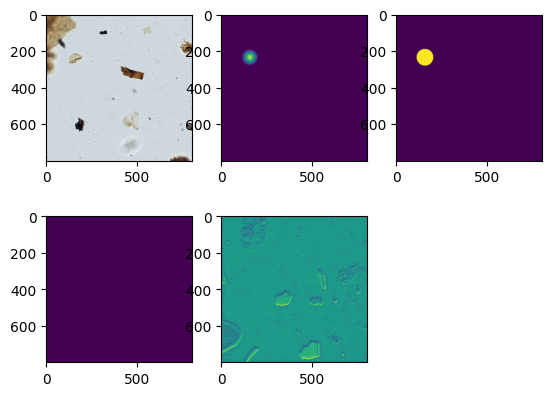

In [61]:
idx = 1

vis_img = cur_img[idx].permute(1,2,0).cpu().numpy()
vis_img -= vis_img.min()
vis_img /= vis_img.max()
vis_disTransformMask = cur_disTransformMask[idx].squeeze().cpu().numpy()
vis_binaryMask = cur_binaryMask[idx].squeeze().cpu().numpy()



plt.subplot(2, 3, 1) # 1 row, 2 columns, 1st plot
plt.imshow(vis_img)

plt.subplot(2, 3, 2) # 1 row, 3 columns, 2nd plot
plt.imshow(vis_disTransformMask)

plt.subplot(2, 3, 3) # 1 row, 3 columns, 3rd plot
plt.imshow(vis_binaryMask)

plt.subplot(2, 3, 4) # 1 row, 2 columns, 1st plot
tmp = output_masks[("segMask", 0)][idx]
tmp = torch.sigmoid(tmp)
tmp = tmp.squeeze().detach().cpu().numpy()>0.5
plt.imshow(tmp)

plt.subplot(2, 3, 5) # 1 row, 2 columns, 1st plot
tmp2 = output_masks[("output", 0)][idx]
tmp2 = tmp2.squeeze().detach().cpu().numpy()
plt.imshow(tmp2)

In [60]:
best_loss, best_epoch_id

(0.3403011034516727, 23)